In [1]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator as RGI, RectBivariateSpline as RBS
from skimage.registration import phase_cross_correlation as pcc
from skimage.transform import rotate
import astra
from numpy.fft import fftshift as SHFT
import matplotlib.pyplot as plt
import multiprocessing as mp
from multiprocessing.pool import ThreadPool
import tomosipo as ts
import functions
from skimage.restoration import estimate_sigma
import torch 
import functions
from scipy.ndimage import sobel, shift
import skimage.registration
from skimage.transform import warp_polar, rotate, rescale

In [2]:
def read_log_data(path, prefix, white, angles, pixels_x, pixels_y):
    det_offset = int(63 * 2)  # in bytes
    det_len = int(pixels_x * pixels_y)
    g = np.zeros((pixels_y, angles, pixels_x), dtype='float32')
    def read_proj(pr):
        g[:, pr, :] = np.fromfile(path + prefix + str(pr+1).zfill(4) + '.tif', dtype='uint16', offset=det_offset, count=det_len).reshape(pixels_y, pixels_x)
        g[:, pr, :] = -np.log(np.maximum(0.001, g[:, pr, :] / white))

    pool = ThreadPool(mp.cpu_count() - 10)
    pool.map(read_proj, np.arange(angles))
    pool.close()

    return g

In [3]:
num_of_projections= 2016
white = 8846
pixels_x = 2016
pixels_y = 1600

path = '/mnt/nas2/negin_data/Ti_Scans/Titanium_cylinder_WaygateM300/1/'
prefix = 'stepcylinder_'

In [4]:
projections = read_log_data(path, prefix, white, num_of_projections, pixels_x, pixels_y)

print(projections.shape)

(1600, 2016, 2016)


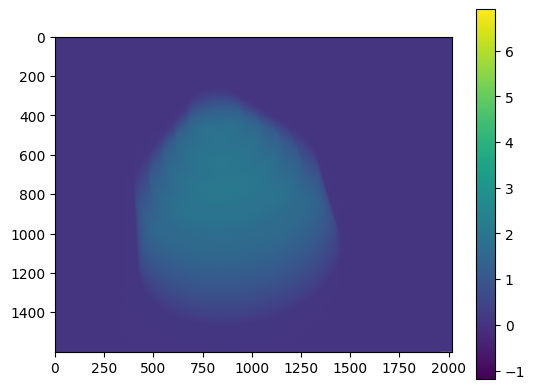

In [5]:
plt.imshow(projections[:,1000,:])
plt.colorbar()

In [10]:
n_rows = 1600
FOV = 2016
n_slices = 1600
detector_rows = 1600
detector_cols = 2016
# projection = projections[:, ::8, :]

projection = np.load('Titanium_cylinder_Waygate_1.npy')

voxel = 0.01773846
sod = 71.50000000
sdd = 806.15781689
rows = 1600
cols = 2016
pixel = 0.20
angles = projection.shape[1]

num_of_projections = projection.shape[1]
angles =  np.linspace(2*np.pi, 0, num = projection.shape[1], endpoint=False)
rot_step = (angles[2]-angles[1])*180/np.pi

det_x = 10.0 
det_y = 0.0
eta = 0.0
theta = 0.0
phi = 0.0



In [37]:
vectors = functions.vectors_astra(pixel, voxel, sod, sdd, rot_step, num_of_projections, det_x, det_y, eta, theta, phi)

proj_geom = astra.create_proj_geom('cone_vec', n_rows, detector_cols, vectors)
vol_geom = astra.create_vol_geom(detector_cols, detector_cols, detector_cols)  
vol_id = astra.data3d.create('-vol', vol_geom)
proj_id = astra.data3d.create('-sino', proj_geom, projection)

reconstruction_id = astra.data3d.create('-vol', vol_geom)
alg_cfg = astra.astra_dict('FDK_CUDA')
alg_cfg['ProjectionDataId'] = proj_id
alg_cfg['ReconstructionDataId'] = reconstruction_id
algorithm_id = astra.algorithm.create(alg_cfg)
astra.algorithm.run(algorithm_id)
reconstruction = astra.data3d.get(reconstruction_id)



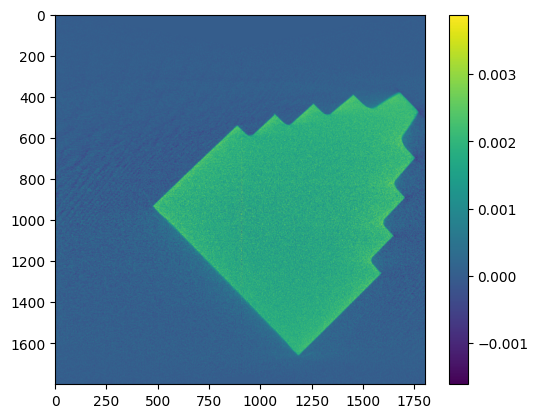

In [48]:
plt.imshow(reconstruction[50:1850,1008,100:1900])
plt.colorbar()
plt.show()